# Exercise - Decoupling of Printed Circuit Boards - 3)

Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Decoupling of Printed Circuit Boards

* Lecture Period: Summer 2024 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/overview?cid=ad2748a23022bc374228b4671f8dc508))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/institute/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Til Hillebrecht and Jan Heßling



### PCB Setup

The printed circuit board (PCB) is shown in the figure below. Having 26 ports in total $(P_1$ to $P_{26})$. Remember, python indices start at 0!
The goal is to increase the frequency where the target impedance (TI) is violated. Therefore, a few things are defined.

* The equivalent circuit of the VRM is a resistor with $50m\Omega$ (connected at $P_1$)
* Impedance of interest $(Z_{PDN})$ is observed at $P_2$ (center of the board/array)
* Remaining ports $P_3$ to $P_{26}$ are used for placing decoupling capacitor
* Decaps are chosen from a library, accessed through the helper function (*get_decap_library()*)
* Target Impedance (TI) is set to $30m\Omega$
* You can place at each port $(P_3$ to $P_{26})$ one decap from the library.




<img title="PCB for Decoupling Optimization" src='figures/pcb_setup.png' width='500'/>

In the following cell:

* First required modules are loaded
* The decap library and the bare board network parameters are loaded
* The VRM network is defined and connected to $P_1$ of the bare board

In [1]:
import helper.helper_function as hp
import matplotlib.pyplot as plt
import random as rand

decap_library = hp.get_decap_library() # get decap library
ntw_board_raw = hp.get_ntw_board("data/ntw_board_pmc.s26p") # load bare board network
ntw_vrm = hp.get_vrm_network(ntw_board_raw, l=0.0) # load VRM network
ntw_board = hp.connect_to_network(ntw_vrm, ntw_board_raw, 0) # connect VRM network to bare board

decap_library

,C,ESL,ESR
0,1.000000e-08,1.000000e-12,0.007
1,1.000000e-07,1.000000e-11,0.010
2,1.000000e-06,5.000000e-11,0.010
3,5.000000e-06,1.000000e-10,0.070
4,1.000000e-05,1.000000e-10,0.100


In the following cell the violation of the target impedance is calculated. Following parameters are required:

* The network under investigation
* The port under investigation (python index)
* the target impedance

Return values are:
* Frequency of violation
* -1 if always violated
* 0 if no violation

In [2]:
hp.get_violation_frequency(ntw_board, 1, target_impedance=0.03)

-1

In the following cell a decap is chosen from the loaded library and connected the ntw board. Here, the decap is chosen randomly.

In [3]:
decap_index = rand.randrange(len(decap_library))
ntw_decap = hp.get_decap_network(decap_library.loc[decap_index], ntw_board=ntw_board)

ntw_decap_terminated = hp.connect_to_network(ntw_decap= ntw_decap, ntw_board = ntw_board)

decap_index

0

In the following cell the different magnitudes of network impedances at $P_2$ are plotted:
* Bare Board: NO Decaps, NO VRM
* VRM Board: NO Decaps, YES VRM
* Decap Board: YES Decap, YES VRM


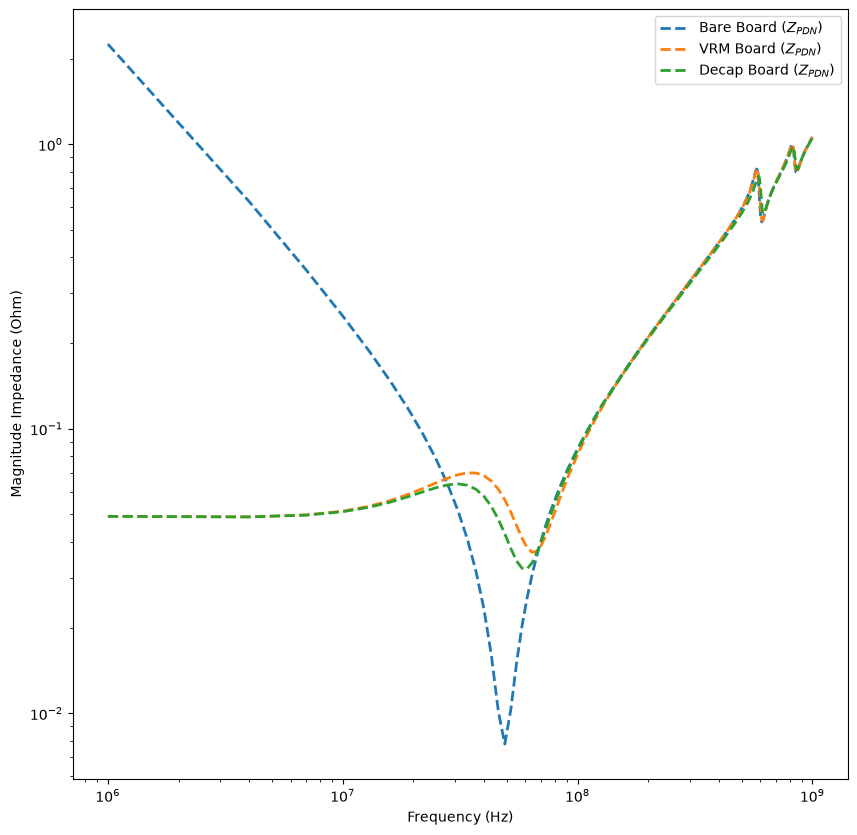

In [4]:
### code cell
import skrf as rf
fig, axs = plt.subplots(1, 1, figsize=(10,10), sharey=False)

axs.loglog(ntw_board_raw.f, abs(ntw_board_raw.z[:, 1, 1]), label='Bare Board $(Z_{PDN}$)', ls = "--", lw= 2)
axs.loglog(ntw_board.f, abs(ntw_board.z[:, 1, 1]), label='VRM Board $(Z_{PDN}$)', ls = "--", lw= 2)

axs.loglog(ntw_decap_terminated.f, abs(ntw_decap_terminated.z[:, 1, 1]), label='Decap Board $(Z_{PDN}$)', ls = "--", lw= 2)

axs.set_xlabel("Frequency (Hz)")
axs.set_ylabel("Magnitude Impedance (Ohm)")
axs.legend()


## Optimization: physical evaluator and dataset

A configuration contains 24 values for P3–P26: 0 is empty and 1–5 selects decap-library row 0–4. Inspection of `connect_to_network` and scikit-rf port ordering confirms that position `i` is passed as `board_port=i+2`; the remaining decap terminal replaces that port, so later indices remain valid.

In [5]:
import numpy as np
import pandas as pd
from copy import deepcopy
SEED, N_POSITIONS = 2026, 24
N_TYPES, OBS_PORT, TARGET = len(decap_library), 1, 0.03
decap_networks = {t: hp.get_decap_network(decap_library.loc[t-1], ntw_board)
                  for t in range(1, N_TYPES+1)}
_cache, _records = {}, []

def violation_rank(f, n):
    if f == 0: return (2, float("inf"), -n)   # no violation: best
    if f == -1: return (0, float("-inf"), -n) # always violated: worst
    return (1, float(f), -n)

def build_configured_network(configuration):
    c = np.asarray(configuration)
    if c.shape != (N_POSITIONS,) or not np.all(c == c.astype(int)):
        raise ValueError("configuration must contain 24 integers")
    c = c.astype(int)
    if np.any((c < 0) | (c > N_TYPES)):
        raise ValueError(f"values must be in [0,{N_TYPES}]")
    network = ntw_board.copy()  # fresh PCB + VRM every time
    for position, decap_type in enumerate(c):
        if decap_type:
            network = hp.connect_to_network(
                decap_networks[int(decap_type)], network, position+2)
    return network

def evaluate_configuration(configuration, return_network=False):
    key = tuple(np.asarray(configuration, dtype=int).tolist())
    if len(key) != N_POSITIONS or any(x < 0 or x > N_TYPES for x in key):
        raise ValueError("invalid length-24 configuration")
    if key not in _cache:
        network = build_configured_network(key)
        frequency = float(hp.get_violation_frequency(network, OBS_PORT, TARGET))
        chosen = [(i, int(t)) for i, t in enumerate(key) if t]
        result = dict(
            configuration=key, violation_frequency=frequency,
            number_of_decaps=len(chosen),
            selected_ports=[f"P{i+3}" for i, _ in chosen],
            selected_python_indices=[i+2 for i, _ in chosen],
            selected_decap_types=[t for _, t in chosen])
        _cache[key] = result
        _records.append({**{f"x{i}": x for i, x in enumerate(key)}, **result})
    result = deepcopy(_cache[key])
    if return_network:
        result["network"] = build_configured_network(key)
    return result

def evaluations_dataframe():
    return pd.DataFrame(_records).copy()

def best_result(results):
    return max(results, key=lambda r:
               violation_rank(r["violation_frequency"], r["number_of_decaps"]))


## Verification: zero and every single-decap design

This evaluates the no-decap case and all (24\times5=120) one-decap cases with the real network. The assertions check the physical-port mapping.

In [6]:
no_decap_result = evaluate_configuration(np.zeros(N_POSITIONS, int))
single_decap_results = []
for position in range(N_POSITIONS):
    for decap_type in range(1, N_TYPES+1):
        c = np.zeros(N_POSITIONS, int)
        c[position] = decap_type
        r = evaluate_configuration(c)
        assert r["selected_ports"] == [f"P{position+3}"]
        assert r["selected_python_indices"] == [position+2]
        assert r["selected_decap_types"] == [decap_type]
        single_decap_results.append(r)
best_one_decap = best_result(single_decap_results)
print("No decaps:", no_decap_result)
print("Best one decap:", best_one_decap)
print("Dataset rows:", len(evaluations_dataframe()))


No decaps: {'configuration': (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0), 'violation_frequency': -1.0, 'number_of_decaps': 0, 'selected_ports': [], 'selected_python_indices': [], 'selected_decap_types': []}
Best one decap: {'configuration': (2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0), 'violation_frequency': 19000000.0, 'number_of_decaps': 1, 'selected_ports': ['P3'], 'selected_python_indices': [2], 'selected_decap_types': [2]}
Dataset rows: 121


## Fast one-hot MLP surrogate

The physical training set is deliberately bounded: in addition to the zero- and one-decap evaluations above, only 144 representative multi-decap configurations are evaluated. Each of the 24 PCB ports P3–P26 has six categories (`0` = empty, `1`–`5` = decap type), so one-hot encoding produces exactly 144 neural-network inputs.

The MLP architecture is **144 → 128 → 64 → 1**. Backpropagation is performed by `MLPRegressor` with the Adam solver. The network only ranks cheap in-memory proposals; the final answer always comes from physical S-parameter verification.


In [ ]:
def random_configuration(g, exact_count=None, max_count=8):
    """Generate a configuration in memory; this performs no physical evaluation."""
    c = np.zeros(N_POSITIONS, dtype=int)
    n = (int(exact_count) if exact_count is not None
         else int(g.integers(0, max_count + 1)))
    if not 0 <= n <= N_POSITIONS:
        raise ValueError("invalid decap count")
    if n:
        positions = g.choice(N_POSITIONS, n, replace=False)
        c[positions] = g.integers(1, N_TYPES + 1, size=n)
    return c


def mutate_configuration(c, g, max_count=8):
    """Cheap add/remove/change/move mutation with no network simulation."""
    c = np.asarray(c, dtype=int).copy()
    used = np.flatnonzero(c)
    empty = np.flatnonzero(c == 0)
    operations = ["change"]
    if len(empty) and len(used) < max_count:
        operations.append("add")
    if len(used):
        operations.append("remove")
    if len(used) and len(empty):
        operations.append("move")
    operation = str(g.choice(operations))

    if operation == "add":
        c[int(g.choice(empty))] = int(g.integers(1, N_TYPES + 1))
    elif operation == "remove":
        c[int(g.choice(used))] = 0
    elif operation == "move":
        source = int(g.choice(used))
        destination = int(g.choice(empty))
        decap_type = int(c[source])
        c[source] = 0
        c[destination] = (int(g.integers(1, N_TYPES + 1))
                          if g.random() < .35 else decap_type)
    elif len(used):
        position = int(g.choice(used))
        alternatives = [t for t in range(1, N_TYPES + 1)
                        if t != c[position]]
        c[position] = int(g.choice(alternatives))
    else:
        c[int(g.choice(empty))] = int(g.integers(1, N_TYPES + 1))
    return c


def surrogate_target(frequency):
    """Map special physical outcomes to an ordered regression target."""
    if frequency == -1:
        return 0.0
    if frequency == 0:
        return float(ntw_board.f[-1] * 1.05)
    return float(frequency)


def component_table(result):
    rows = []
    for position, encoded_type in enumerate(result["configuration"]):
        if encoded_type:
            library_index = int(encoded_type) - 1
            decap = decap_library.loc[library_index]
            rows.append(dict(
                PCB_port=f"P{position + 3}",
                encoded_type=int(encoded_type),
                C_F=decap.C,
                ESR_Ohm=decap.ESR,
                ESL_H=decap.ESL))
    return pd.DataFrame(rows)


In [ ]:
# Small, controlled multi-decap physical training set.
# Six count levels x 24 samples = 144 additional configurations at most.
training_rng = np.random.default_rng(SEED + 1)
controlled_configurations = []
for decap_count in (2, 3, 4, 5, 6, 8):
    controlled_configurations.extend(
        random_configuration(training_rng, exact_count=decap_count)
        for _ in range(24))

controlled_results = [
    evaluate_configuration(c) for c in controlled_configurations]
training_data = evaluations_dataframe().drop_duplicates(
    subset=[f"x{i}" for i in range(N_POSITIONS)]).copy()

print("Controlled multi-decap configurations requested:",
      len(controlled_configurations))
print("Number of unique physical training examples:", len(training_data))
print("Total cached physical evaluations:", len(_cache))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mlp_features = [f"x{i}" for i in range(N_POSITIONS)]
X = training_data[mlp_features].astype(int)
y = (training_data["violation_frequency"].map(surrogate_target).astype(float)
     / 1e6)  # MHz improves Adam conditioning without changing target ordering.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED)

one_hot_categories = [np.arange(N_TYPES + 1) for _ in range(N_POSITIONS)]
mlp_surrogate = Pipeline([
    ("one_hot", OneHotEncoder(
        categories=one_hot_categories,
        handle_unknown="ignore",
        sparse_output=False)),
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=SEED))
])
mlp_surrogate.fit(X_train, y_train)

encoded_width = mlp_surrogate.named_steps["one_hot"].transform(
    X_train.iloc[:1]).shape[1]
assert encoded_width == N_POSITIONS * (N_TYPES + 1) == 144

y_pred = mlp_surrogate.predict(X_test)
mlp_mae = mean_absolute_error(y_test, y_pred)
mlp_rmse = mean_squared_error(y_test, y_pred) ** 0.5
mlp_r2 = r2_score(y_test, y_pred)

print(f"Number of training examples: {len(X_train)}")
print(f"Held-out test examples: {len(X_test)}")
print(f"One-hot input width: {encoded_width}")
print(f"MAE:  {mlp_mae:.6g} MHz")
print(f"RMSE: {mlp_rmse:.6g} MHz")
print(f"R²:   {mlp_r2:.6f}")

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, y_pred, alpha=.7,
           edgecolor="none", label="Held-out physical examples")
limits = np.array([min(y_test.min(), y_pred.min()),
                   max(y_test.max(), y_pred.max())])
ax.plot(limits, limits, "k--", lw=2, label="Perfect prediction (y=x)")
ax.set(xlim=limits, ylim=limits,
       xlabel="True transformed violation frequency (MHz)",
       ylabel="MLP-predicted violation frequency (MHz)",
       title="One-hot MLP: true vs predicted")
ax.grid(True, alpha=.25)
ax.legend()
plt.show()


In [ ]:
# Generate and score proposals entirely in memory (no physical simulation).
candidate_rng = np.random.default_rng(SEED + 2)
physical_training_results = ([no_decap_result] + single_decap_results +
                             controlled_results)
training_best = best_result(physical_training_results)
base = np.asarray(training_best["configuration"], dtype=int)

candidate_map = {tuple(base): base.copy()}
for _ in range(15000):
    candidate = base.copy()
    for _ in range(int(candidate_rng.integers(1, 8))):
        candidate = mutate_configuration(candidate, candidate_rng, max_count=8)
    candidate_map.setdefault(tuple(candidate), candidate)

for _ in range(15000):
    decap_count = int(candidate_rng.integers(0, 9))
    candidate = random_configuration(candidate_rng, exact_count=decap_count)
    candidate_map.setdefault(tuple(candidate), candidate)

candidate_array = np.asarray(list(candidate_map.values()), dtype=int)
candidate_frame = pd.DataFrame(candidate_array, columns=mlp_features)
candidate_frame["predicted_frequency"] = mlp_surrogate.predict(
    candidate_frame[mlp_features])
candidate_frame["number_of_decaps"] = np.count_nonzero(candidate_array, axis=1)
candidate_frame.sort_values(
    ["predicted_frequency", "number_of_decaps"],
    ascending=[False, True], inplace=True)

# Only these 25 finalists invoke the cache-backed physical evaluator.
top_candidate_count = min(25, len(candidate_frame))
top_candidates = candidate_frame.head(top_candidate_count)
verified_results = [
    evaluate_configuration(row[mlp_features].to_numpy(dtype=int))
    for _, row in top_candidates.iterrows()]
best_mlp_verified = best_result(verified_results)
best_mlp_prediction = float(top_candidates.iloc[0]["predicted_frequency"])

verified_with_network = evaluate_configuration(
    best_mlp_verified["configuration"], return_network=True)
best_mlp_network = verified_with_network.pop("network")
assert hp.get_violation_frequency(best_mlp_network, OBS_PORT, TARGET) == \
       verified_with_network["violation_frequency"]

print(f"Cheap unique candidates ranked: {len(candidate_frame)}")
print(f"Final candidates physically verified: {top_candidate_count}")
print(f"Best MLP predicted frequency: {best_mlp_prediction:.6g} MHz")
print(f"Actual physically verified frequency: "
      f"{best_mlp_verified['violation_frequency'] / 1e6:.6g} MHz")
print(f"Number of decaps: {best_mlp_verified['number_of_decaps']}")
print("Selected ports:", best_mlp_verified["selected_ports"])
print("Selected decap types:", best_mlp_verified["selected_decap_types"])
print("Selected decap C, ESR, and ESL:")
display(component_table(best_mlp_verified))


In [ ]:
final_comparison = pd.DataFrame([
    dict(search="exhaustive 1 decap", **best_one_decap),
    dict(search="one-hot MLP (physically verified)", **best_mlp_verified)
])[["search", "violation_frequency", "number_of_decaps",
    "selected_ports", "selected_decap_types"]]
display(final_comparison)

fig, ax = plt.subplots(figsize=(11, 7))
ax.loglog(best_mlp_network.f, abs(best_mlp_network.z[:, 1, 1]), lw=2.5,
          label="Physically verified one-hot MLP design")
ax.axhline(TARGET, color="black", ls=":", lw=2,
           label=f"Target = {TARGET * 1e3:.0f} mΩ")
ax.set(xlabel="Frequency (Hz)", ylabel=r"$|Z_{PDN}|$ (Ohm)",
       title="PDN impedance of the physically verified MLP design")
ax.grid(True, which="both", alpha=.25)
ax.legend()
plt.show()
